V-JEPA

In [10]:
import copy
import math
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import MovingMNIST
import matplotlib.pyplot as plt

In [13]:
NUM_FRAMES = 10
IMAGE_SIZE = 64

TEMPORAL_PATCH = 2
PATCH_SIZE = 16

ENCODER_DIM = 128
PREDICTOR_DIM = 64

ENCODER_DEPTH = 6
PREDICTOR_DEPTH = 4

NUM_HEADS = 4

MASK_GROUPS = [
    ("short", 8, 0.15),
    ("long", 2, 0.70),
]

In [3]:
def pick_device():
    if torch.cuda.is_available():
        return "cuda"
    return "cpu"


device = pick_device()
print("Device:", device)

Device: cuda


In [5]:
# Positional Encoding 

def sincos_1d(n, dim):
    pos = torch.arange(n).unsqueeze(1).float()

    div = torch.exp(
        torch.arange(0, dim, 2).float()
        * (-math.log(10000.0) / dim)
    )

    pe = torch.zeros(n, dim)
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)

    return pe


def sincos_2d(h, w, dim):
    assert dim % 4 == 0

    sub_dim = dim // 4

    yy, xx = torch.meshgrid(
        torch.arange(h),
        torch.arange(w),
        indexing="ij"
    )

    yy = yy.reshape(-1).float()
    xx = xx.reshape(-1).float()

    div = torch.exp(
        torch.arange(0, sub_dim * 2, 2).float()
        * (-math.log(10000.0) / (sub_dim * 2))
    )

    pe_y = torch.cat(
        [torch.sin(yy[:, None] * div), torch.cos(yy[:, None] * div)],
        dim=-1
    )

    pe_x = torch.cat(
        [torch.sin(xx[:, None] * div), torch.cos(xx[:, None] * div)],
        dim=-1
    )

    return torch.cat([pe_y, pe_x], dim=-1)


def sincos_3d(t, h, w, dim, temporal_fraction=0.25):
    temporal_dim = int(dim * temporal_fraction)

    if temporal_dim % 2 != 0:
        temporal_dim += 1

    spatial_dim = dim - temporal_dim

    pe_t = sincos_1d(t, temporal_dim)
    pe_s = sincos_2d(h, w, spatial_dim)

    pe = torch.zeros(t * h * w, dim)

    pe[:, :temporal_dim] = (
        pe_t.unsqueeze(1)
        .expand(t, h * w, temporal_dim)
        .reshape(-1, temporal_dim)
    )

    pe[:, temporal_dim:] = (
        pe_s.unsqueeze(0)
        .expand(t, h * w, spatial_dim)
        .reshape(-1, spatial_dim)
    )

    return pe

In [6]:
# Transformer Block

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim, eps=1e-6)
        self.norm2 = nn.LayerNorm(dim, eps=1e-6)

        self.attention = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            batch_first=True
        )

        hidden_dim = int(dim * mlp_ratio)

        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, dim),
        )

    def forward(self, x):
        h = self.norm1(x)

        attention_output, _ = self.attention(
            h,
            h,
            h,
            need_weights=False
        )

        x = x + attention_output
        x = x + self.mlp(self.norm2(x))

        return x

In [7]:
# Dataset

class MovingMNISTVideos(Dataset):
    def __init__(self, root="./data", num_frames=10):
        self.base_dataset = MovingMNIST(root=root, download=True)
        self.num_frames = num_frames

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        video = self.base_dataset[index]

        if isinstance(video, (tuple, list)):
            video = video[0]

        video = video.float() / 255.0

        step = max(1, video.size(0) // self.num_frames)
        video = video[::step][:self.num_frames]

        video = video.permute(1, 0, 2, 3).contiguous()

        video = video - 0.5

        return video

In [8]:
dataset = MovingMNISTVideos(num_frames=NUM_FRAMES)

video = dataset[0]

print("Video shape:", video.shape)

0.3%

100.0%


Video shape: torch.Size([1, 10, 64, 64])


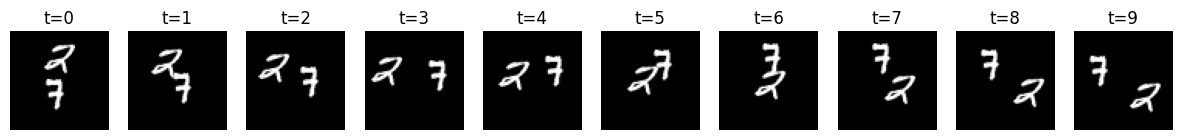

In [11]:
fig, axes = plt.subplots(1, NUM_FRAMES, figsize=(15, 2))

for i in range(NUM_FRAMES):
    axes[i].imshow(video[0, i], cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"t={i}")

plt.show()

In [14]:
# Tubelect projection demo 

tubelet_projection = nn.Conv3d(
    in_channels=1,
    out_channels=ENCODER_DIM,
    kernel_size=(TEMPORAL_PATCH, PATCH_SIZE, PATCH_SIZE),
    stride=(TEMPORAL_PATCH, PATCH_SIZE, PATCH_SIZE),
)

x = video.unsqueeze(0)

tubelets = tubelet_projection(x)

print("After Conv3D:", tubelets.shape)

After Conv3D: torch.Size([1, 128, 5, 4, 4])


In [15]:
tokens = tubelets.flatten(2).transpose(1, 2)

print("After flattening:", tokens.shape)

After flattening: torch.Size([1, 80, 128])


In [16]:
# Video encoder 

class VideoEncoder(nn.Module):
    def __init__(
        self,
        num_frames=10,
        temporal_patch=2,
        image_size=64,
        patch_size=16,
        in_channels=1,
        dim=128,
        depth=6,
        heads=4,
    ):
        super().__init__()

        self.temporal_grid = num_frames // temporal_patch
        self.spatial_grid = image_size // patch_size

        self.num_patches = (
            self.temporal_grid
            * self.spatial_grid
            * self.spatial_grid
        )

        self.dim = dim

        self.tubelet_projection = nn.Conv3d(
            in_channels,
            dim,
            kernel_size=(temporal_patch, patch_size, patch_size),
            stride=(temporal_patch, patch_size, patch_size),
        )

        position = sincos_3d(
            self.temporal_grid,
            self.spatial_grid,
            self.spatial_grid,
            dim,
        )

        self.register_buffer("position", position)

        self.blocks = nn.ModuleList([
            Block(dim, heads)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(dim, eps=1e-6)

    def forward(self, videos, token_indices=None):
        tokens = self.tubelet_projection(videos)

        tokens = tokens.flatten(2).transpose(1, 2)

        batch_size, num_tokens, dim = tokens.shape

        if token_indices is None:
            token_indices = torch.arange(
                num_tokens,
                device=videos.device
            ).expand(batch_size, -1)

            x = tokens + self.position[token_indices]

        else:
            selected_tokens = tokens.gather(
                dim=1,
                index=token_indices.unsqueeze(-1).expand(-1, -1, dim)
            )

            x = selected_tokens + self.position[token_indices]

        for block in self.blocks:
            x = block(x)

        return self.norm(x)

In [17]:
# Test the encoder 

encoder = VideoEncoder(
    num_frames=NUM_FRAMES,
    temporal_patch=TEMPORAL_PATCH,
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    dim=ENCODER_DIM,
    depth=ENCODER_DEPTH,
    heads=NUM_HEADS,
).to(device)

video_batch = video.unsqueeze(0).to(device)

encoded_tokens = encoder(video_batch)

print("Encoded tokens:", encoded_tokens.shape)
print("Number of patches:", encoder.num_patches)
print("Temporal grid:", encoder.temporal_grid)
print("Spatial grid:", encoder.spatial_grid)

Encoded tokens: torch.Size([1, 80, 128])
Number of patches: 80
Temporal grid: 5
Spatial grid: 4


In [18]:
# Predictor 

class Predictor(nn.Module):
    def __init__(
        self,
        temporal_grid,
        spatial_grid,
        encoder_dim=128,
        predictor_dim=64,
        depth=4,
        heads=4,
    ):
        super().__init__()

        self.input_projection = nn.Linear(encoder_dim, predictor_dim)
        self.output_projection = nn.Linear(predictor_dim, encoder_dim)

        self.mask_token = nn.Parameter(
            torch.zeros(1, 1, predictor_dim)
        )

        nn.init.trunc_normal_(self.mask_token, std=0.02)

        position = sincos_3d(
            temporal_grid,
            spatial_grid,
            spatial_grid,
            predictor_dim,
        )

        self.register_buffer("position", position)

        self.blocks = nn.ModuleList([
            Block(predictor_dim, heads)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(predictor_dim, eps=1e-6)

    def forward(self, context_tokens, context_indices, target_indices):
        batch_size = context_tokens.size(0)
        num_target_tokens = target_indices.size(1)

        context_tokens = self.input_projection(context_tokens)
        context_tokens = context_tokens + self.position[context_indices]

        mask_tokens = self.mask_token.expand(
            batch_size,
            num_target_tokens,
            -1,
        )

        mask_tokens = mask_tokens + self.position[target_indices]

        x = torch.cat([context_tokens, mask_tokens], dim=1)

        for block in self.blocks:
            x = block(x)

        predicted_tokens = x[:, -num_target_tokens:]

        predicted_tokens = self.norm(predicted_tokens)
        predicted_tokens = self.output_projection(predicted_tokens)

        return predicted_tokens

In [19]:
# Mask utilities 

def block_size(grid_size, scale, aspect_ratio=1.0):
    area = scale * grid_size * grid_size

    height = round(math.sqrt(area * aspect_ratio))
    width = round(math.sqrt(area / aspect_ratio))

    height = max(1, min(grid_size, height))
    width = max(1, min(grid_size, width))

    return height, width


def expand_spatial_tubes(spatial_cells, temporal_grid, spatial_grid):
    token_indices = []

    for t in range(temporal_grid):
        for spatial_index in spatial_cells:
            token_index = (
                t * spatial_grid * spatial_grid
                + spatial_index
            )

            token_indices.append(token_index)

    return sorted(token_indices)


def sample_spatial_tubes(
    num_blocks,
    block_height,
    block_width,
    spatial_grid,
    rng,
    min_visible_cells,
):
    all_spatial_cells = set(range(spatial_grid * spatial_grid))

    best_masked = None
    best_visible = None

    for _ in range(50):
        masked = set()

        for _ in range(num_blocks):
            top = rng.randint(0, spatial_grid - block_height)
            left = rng.randint(0, spatial_grid - block_width)

            for r in range(top, top + block_height):
                for c in range(left, left + block_width):
                    masked.add(r * spatial_grid + c)

        visible = all_spatial_cells - masked

        if best_visible is None or len(visible) > len(best_visible):
            best_masked = masked
            best_visible = visible

        if len(visible) >= min_visible_cells:
            return masked, visible

    return best_masked, best_visible


def sample_vjepa_masks(
    batch_size,
    temporal_grid,
    spatial_grid,
    rng=None,
    min_context_tokens=8,
    aspect_ratio_range=(0.75, 1.5),
):
    if rng is None:
        rng = random

    min_visible_cells = max(
        1,
        math.ceil(min_context_tokens / temporal_grid)
    )

    groups = []

    for label, num_blocks, scale in MASK_GROUPS:
        aspect_ratio = rng.uniform(*aspect_ratio_range)

        block_height, block_width = block_size(
            spatial_grid,
            scale,
            aspect_ratio,
        )

        context_spatial = []
        target_spatial = []

        for _ in range(batch_size):
            masked, visible = sample_spatial_tubes(
                num_blocks,
                block_height,
                block_width,
                spatial_grid,
                rng,
                min_visible_cells,
            )

            context_spatial.append(sorted(visible))
            target_spatial.append(sorted(masked))

        context_length = min(len(x) for x in context_spatial)
        target_length = min(len(x) for x in target_spatial)

        context_indices = []
        target_indices = []

        for visible_cells, masked_cells in zip(
            context_spatial,
            target_spatial,
        ):
            visible_cells = rng.sample(visible_cells, context_length)
            masked_cells = rng.sample(masked_cells, target_length)

            context_indices.append(
                expand_spatial_tubes(
                    sorted(visible_cells),
                    temporal_grid,
                    spatial_grid,
                )
            )

            target_indices.append(
                expand_spatial_tubes(
                    sorted(masked_cells),
                    temporal_grid,
                    spatial_grid,
                )
            )

        groups.append({
            "label": label,
            "num_blocks": num_blocks,
            "block_size": (block_height, block_width),
            "context_indices": context_indices,
            "target_indices": target_indices,
        })

    return groups

In [20]:
# Visualize one mask 

rng = random.Random(0)

groups = sample_vjepa_masks(
    batch_size=1,
    temporal_grid=encoder.temporal_grid,
    spatial_grid=encoder.spatial_grid,
    rng=rng,
)

group = groups[0]

print("Mask type:", group["label"])
print("Block size:", group["block_size"])
print("Context tokens:", len(group["context_indices"][0]))
print("Target tokens:", len(group["target_indices"][0]))

Mask type: short
Block size: (2, 1)
Context tokens: 30
Target tokens: 50


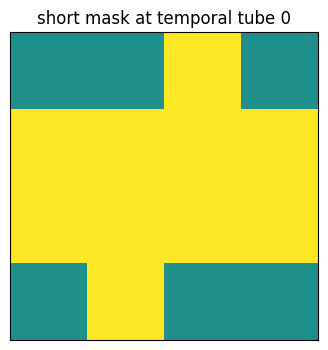

In [21]:
def visualize_mask(group, temporal_grid, spatial_grid, frame_id=0):
    context = set(group["context_indices"][0])
    target = set(group["target_indices"][0])

    grid = torch.zeros(spatial_grid, spatial_grid)

    for r in range(spatial_grid):
        for c in range(spatial_grid):
            token_index = (
                frame_id * spatial_grid * spatial_grid
                + r * spatial_grid
                + c
            )

            if token_index in context:
                grid[r, c] = 1

            if token_index in target:
                grid[r, c] = 2

    plt.figure(figsize=(4, 4))
    plt.imshow(grid, vmin=0, vmax=2)
    plt.title(f"{group['label']} mask at temporal tube {frame_id}")
    plt.xticks([])
    plt.yticks([])
    plt.show()


visualize_mask(
    group,
    encoder.temporal_grid,
    encoder.spatial_grid,
    frame_id=0,
)

In [22]:
# EMA and optimizer helpers 

@torch.no_grad()
def ema_update(target_encoder, online_encoder, momentum):
    for target_param, online_param in zip(
        target_encoder.parameters(),
        online_encoder.parameters(),
    ):
        target_param.mul_(momentum)
        target_param.add_(
            online_param.detach(),
            alpha=1.0 - momentum,
        )


def param_groups(modules, weight_decay):
    named_parameters = []

    for module in modules:
        named_parameters.extend([
            (name, param)
            for name, param in module.named_parameters()
            if param.requires_grad
        ])

    decay = []
    no_decay = []

    for name, param in named_parameters:
        if param.ndim < 2 or name.endswith("bias"):
            no_decay.append(param)
        else:
            decay.append(param)

    return [
        {
            "params": decay,
            "weight_decay": weight_decay,
        },
        {
            "params": no_decay,
            "weight_decay": 0.0,
        },
    ]

In [23]:
# One forward pass through the predictor

batch_size = 4

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    drop_last=True,
)

videos = next(iter(loader)).to(device)

context_encoder = VideoEncoder(
    num_frames=NUM_FRAMES,
    temporal_patch=TEMPORAL_PATCH,
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    dim=ENCODER_DIM,
    depth=ENCODER_DEPTH,
    heads=NUM_HEADS,
).to(device)

target_encoder = copy.deepcopy(context_encoder).to(device)

for param in target_encoder.parameters():
    param.requires_grad_(False)

predictor = Predictor(
    temporal_grid=context_encoder.temporal_grid,
    spatial_grid=context_encoder.spatial_grid,
    encoder_dim=ENCODER_DIM,
    predictor_dim=PREDICTOR_DIM,
    depth=PREDICTOR_DEPTH,
    heads=NUM_HEADS,
).to(device)

rng = random.Random(0)

groups = sample_vjepa_masks(
    batch_size=videos.size(0),
    temporal_grid=context_encoder.temporal_grid,
    spatial_grid=context_encoder.spatial_grid,
    rng=rng,
)

group = groups[0]

context_indices = torch.tensor(
    group["context_indices"],
    device=device,
)

target_indices = torch.tensor(
    group["target_indices"],
    device=device,
)

with torch.no_grad():
    full_target_tokens = target_encoder(videos)

context_tokens = context_encoder(videos, context_indices)

predicted_tokens = predictor(
    context_tokens,
    context_indices,
    target_indices,
)

target_tokens = full_target_tokens.gather(
    dim=1,
    index=target_indices.unsqueeze(-1).expand(
        -1,
        -1,
        ENCODER_DIM,
    )
)

loss = (predicted_tokens - target_tokens).abs().mean()

print("Context tokens:", context_tokens.shape)
print("Predicted tokens:", predicted_tokens.shape)
print("Target tokens:", target_tokens.shape)
print("Loss:", loss.item())

Context tokens: torch.Size([4, 15, 128])
Predicted tokens: torch.Size([4, 50, 128])
Target tokens: torch.Size([4, 50, 128])
Loss: 0.8780349493026733


In [24]:
# Training function 

def train(
    epochs=5,
    batch_size=32,
    learning_rate=3e-4,
    weight_decay=0.05,
    ema_start=0.998,
    ema_end=1.0,
):
    dataset = MovingMNISTVideos(num_frames=NUM_FRAMES)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        drop_last=True,
    )

    context_encoder = VideoEncoder(
        num_frames=NUM_FRAMES,
        temporal_patch=TEMPORAL_PATCH,
        image_size=IMAGE_SIZE,
        patch_size=PATCH_SIZE,
        dim=ENCODER_DIM,
        depth=ENCODER_DEPTH,
        heads=NUM_HEADS,
    ).to(device)

    target_encoder = copy.deepcopy(context_encoder).to(device)

    for param in target_encoder.parameters():
        param.requires_grad_(False)

    predictor = Predictor(
        temporal_grid=context_encoder.temporal_grid,
        spatial_grid=context_encoder.spatial_grid,
        encoder_dim=ENCODER_DIM,
        predictor_dim=PREDICTOR_DIM,
        depth=PREDICTOR_DEPTH,
        heads=NUM_HEADS,
    ).to(device)

    optimizer = torch.optim.AdamW(
        param_groups([context_encoder, predictor], weight_decay),
        lr=learning_rate,
    )

    total_steps = epochs * len(loader)
    step = 0

    rng = random.Random(0)

    losses_per_group = {
        label: []
        for label, _, _ in MASK_GROUPS
    }

    print("Tubelet grid:")
    print("Temporal:", context_encoder.temporal_grid)
    print("Spatial:", context_encoder.spatial_grid)
    print("Number of patches:", context_encoder.num_patches)

    for epoch in range(epochs):
        for videos in loader:
            videos = videos.to(device)
            batch_size = videos.size(0)

            groups = sample_vjepa_masks(
                batch_size=batch_size,
                temporal_grid=context_encoder.temporal_grid,
                spatial_grid=context_encoder.spatial_grid,
                rng=rng,
            )

            with torch.no_grad():
                full_target_tokens = target_encoder(videos)
                full_target_tokens = F.layer_norm(
                    full_target_tokens,
                    (context_encoder.dim,),
                )

            losses = {}

            for group in groups:
                context_indices = torch.tensor(
                    group["context_indices"],
                    device=device,
                )

                target_indices = torch.tensor(
                    group["target_indices"],
                    device=device,
                )

                context_tokens = context_encoder(
                    videos,
                    context_indices,
                )

                predicted_tokens = predictor(
                    context_tokens,
                    context_indices,
                    target_indices,
                )

                target_tokens = full_target_tokens.gather(
                    dim=1,
                    index=target_indices.unsqueeze(-1).expand(
                        -1,
                        -1,
                        context_encoder.dim,
                    )
                )

                group_loss = (
                    predicted_tokens - target_tokens
                ).abs().mean()

                losses[group["label"]] = group_loss

            loss = sum(losses.values()) / len(losses)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            momentum = ema_start + (
                ema_end - ema_start
            ) * (step / max(1, total_steps - 1))

            ema_update(
                target_encoder,
                context_encoder,
                momentum,
            )

            for label, value in losses.items():
                losses_per_group[label].append(value.item())

            if step % 25 == 0:
                message = " ".join(
                    f"{label}={value.item():.4f}"
                    for label, value in losses.items()
                )

                print(
                    f"epoch={epoch} "
                    f"step={step:5d} "
                    f"{message} "
                    f"ema={momentum:.4f}"
                )

            step += 1

    return {
        "context_encoder": context_encoder,
        "target_encoder": target_encoder,
        "predictor": predictor,
        "losses_per_group": losses_per_group,
        "loader": loader,
        "device": device,
    }

In [25]:
# Train 
result = train(
    epochs=5,
    batch_size=32,
)

Tubelet grid:
Temporal: 5
Spatial: 4
Number of patches: 80
epoch=0 step=    0 short=0.8538 long=0.8502 ema=0.9980
epoch=0 step=   25 short=0.3954 long=0.3962 ema=0.9980
epoch=0 step=   50 short=0.2338 long=0.2338 ema=0.9981
epoch=0 step=   75 short=0.1494 long=0.1500 ema=0.9981
epoch=0 step=  100 short=0.1104 long=0.1104 ema=0.9981
epoch=0 step=  125 short=0.0932 long=0.0943 ema=0.9982
epoch=0 step=  150 short=0.0790 long=0.0800 ema=0.9982
epoch=0 step=  175 short=0.0675 long=0.0692 ema=0.9982
epoch=0 step=  200 short=0.0597 long=0.0628 ema=0.9983
epoch=0 step=  225 short=0.0585 long=0.0571 ema=0.9983
epoch=0 step=  250 short=0.0527 long=0.0538 ema=0.9983
epoch=0 step=  275 short=0.0481 long=0.0494 ema=0.9984
epoch=0 step=  300 short=0.0448 long=0.0476 ema=0.9984
epoch=1 step=  325 short=0.0452 long=0.0453 ema=0.9984
epoch=1 step=  350 short=0.0422 long=0.0425 ema=0.9984
epoch=1 step=  375 short=0.0429 long=0.0444 ema=0.9985
epoch=1 step=  400 short=0.0437 long=0.0428 ema=0.9985
epoch=

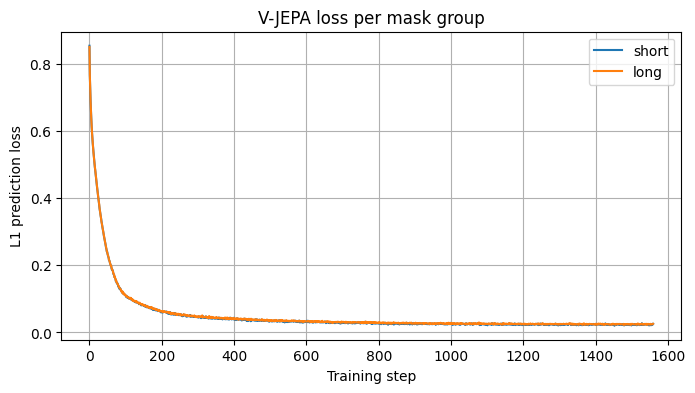

In [26]:
losses = result["losses_per_group"]

plt.figure(figsize=(8, 4))

for label, values in losses.items():
    plt.plot(values, label=label)

plt.xlabel("Training step")
plt.ylabel("L1 prediction loss")
plt.title("V-JEPA loss per mask group")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# Get one batch and one mask 

context_encoder = result["context_encoder"]
target_encoder = result["target_encoder"]
predictor = result["predictor"]
loader = result["loader"]
device = result["device"]

context_encoder.eval()
target_encoder.eval()
predictor.eval()

videos = next(iter(loader)).to(device)

rng = random.Random(123)

groups = sample_vjepa_masks(
    batch_size=videos.size(0),
    temporal_grid=context_encoder.temporal_grid,
    spatial_grid=context_encoder.spatial_grid,
    rng=rng,
)

group = groups[0]

context_indices = torch.tensor(
    group["context_indices"],
    device=device,
)

target_indices = torch.tensor(
    group["target_indices"],
    device=device,
)

print("Mask group:", group["label"])
print("Context shape:", context_indices.shape)
print("Target shape:", target_indices.shape)

Mask group: short
Context shape: torch.Size([32, 15])
Target shape: torch.Size([32, 35])


In [28]:
# Compute prediction and target tokens

with torch.no_grad():
    full_target_tokens = target_encoder(videos)

    context_tokens = context_encoder(
        videos,
        context_indices,
    )

    predicted_tokens = predictor(
        context_tokens,
        context_indices,
        target_indices,
    )

    target_tokens = full_target_tokens.gather(
        dim=1,
        index=target_indices.unsqueeze(-1).expand(
            -1,
            -1,
            context_encoder.dim,
        )
    )

print("Predicted tokens:", predicted_tokens.shape)
print("Target tokens:", target_tokens.shape)

Predicted tokens: torch.Size([32, 35, 128])
Target tokens: torch.Size([32, 35, 128])


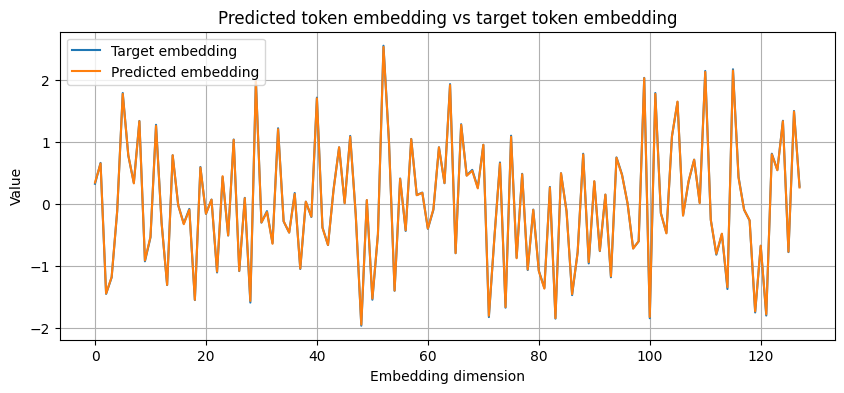

In [29]:
# Visualize predicted vs target embeddings 

sample_id = 0
token_id = 0

pred_vec = predicted_tokens[sample_id, token_id].cpu()
target_vec = target_tokens[sample_id, token_id].cpu()

plt.figure(figsize=(10, 4))

plt.plot(target_vec, label="Target embedding")
plt.plot(pred_vec, label="Predicted embedding")

plt.title("Predicted token embedding vs target token embedding")
plt.xlabel("Embedding dimension")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

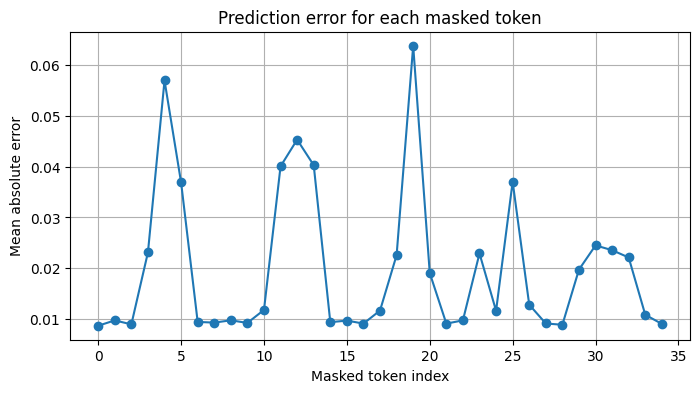

In [30]:
# Error per target token 

with torch.no_grad():
    token_errors = (
        predicted_tokens - target_tokens
    ).abs().mean(dim=-1)

errors = token_errors[sample_id].cpu()

plt.figure(figsize=(8, 4))

plt.plot(errors, marker="o")

plt.title("Prediction error for each masked token")
plt.xlabel("Masked token index")
plt.ylabel("Mean absolute error")
plt.grid(True)

plt.show()

In [31]:
# Map token error back to video grid 

def token_index_to_thw(token_index, temporal_grid, spatial_grid):
    spatial_area = spatial_grid * spatial_grid

    t = token_index // spatial_area
    rem = token_index % spatial_area

    h = rem // spatial_grid
    w = rem % spatial_grid

    return int(t), int(h), int(w)


error_grid = torch.full(
    (
        context_encoder.temporal_grid,
        context_encoder.spatial_grid,
        context_encoder.spatial_grid,
    ),
    float("nan"),
)

sample_target_indices = target_indices[sample_id].cpu()
sample_errors = token_errors[sample_id].cpu()

for idx, error in zip(sample_target_indices, sample_errors):
    t, h, w = token_index_to_thw(
        int(idx),
        context_encoder.temporal_grid,
        context_encoder.spatial_grid,
    )

    error_grid[t, h, w] = error

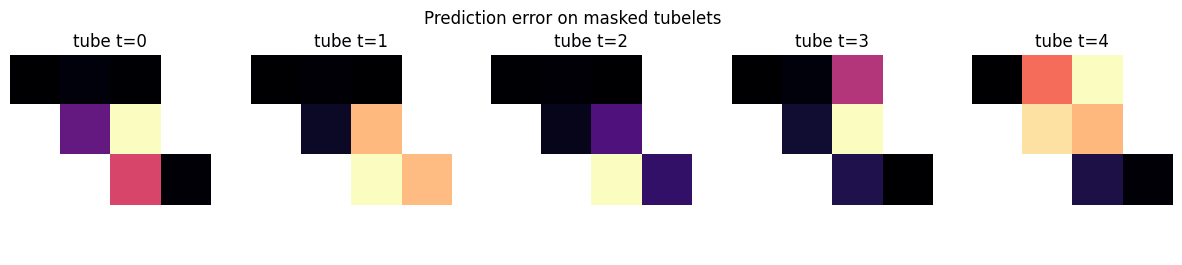

In [32]:
fig, axes = plt.subplots(
    1,
    context_encoder.temporal_grid,
    figsize=(15, 3),
)

for t in range(context_encoder.temporal_grid):
    axes[t].imshow(error_grid[t], cmap="magma")
    axes[t].set_title(f"tube t={t}")
    axes[t].axis("off")

plt.suptitle("Prediction error on masked tubelets")
plt.show()

In [33]:
# Visualize original video with masked tublets 

def make_mask_grid(indices, temporal_grid, spatial_grid):
    mask = torch.zeros(
        temporal_grid,
        spatial_grid,
        spatial_grid,
    )

    for idx in indices:
        t, h, w = token_index_to_thw(
            int(idx),
            temporal_grid,
            spatial_grid,
        )

        mask[t, h, w] = 1

    return mask


target_mask_grid = make_mask_grid(
    target_indices[sample_id].cpu(),
    context_encoder.temporal_grid,
    context_encoder.spatial_grid,
)

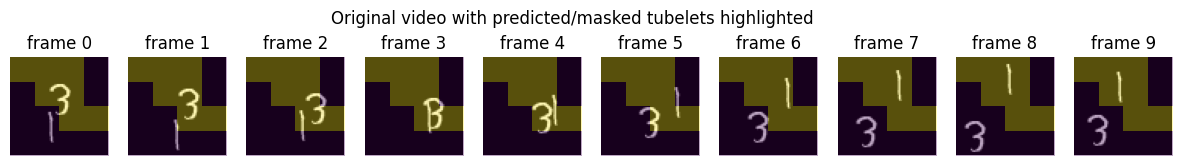

In [34]:
fig, axes = plt.subplots(
    1,
    NUM_FRAMES,
    figsize=(15, 2),
)

video_cpu = videos[sample_id, 0].cpu()

for frame_id in range(NUM_FRAMES):
    axes[frame_id].imshow(video_cpu[frame_id], cmap="gray")

    tube_t = frame_id // TEMPORAL_PATCH

    axes[frame_id].imshow(
        target_mask_grid[tube_t],
        alpha=0.35,
        extent=[0, IMAGE_SIZE, IMAGE_SIZE, 0],
    )

    axes[frame_id].axis("off")
    axes[frame_id].set_title(f"frame {frame_id}")

plt.suptitle("Original video with predicted/masked tubelets highlighted")
plt.show()